# Exp 0 — V2 dataset: validation and exploratory data analysis
**Question:** what is in the ExpenseGuard V2 dataset, how many classes/outcomes are there, and is it trustworthy before any model is run?
**Edition:** semantic edition of V2 (facts live only in free-text notes; see `docs/dataset_v2_card.md`).
**Note:** there is no video data in this project; the data are expense claims (bills + free-text description) plus a policy corpus and enterprise tables. This notebook is audit code, so it may read the private ground truth. Model-facing code must not. No LLM calls, cost $0.

In [1]:
import json, sys, os
from pathlib import Path
from collections import Counter
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C
pd.set_option('display.width', 200, 'display.max_columns', 40)
jl = lambda p: [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]
cases = jl(C.CASES/'all_cases.jsonl'); gt = jl(C.GROUND_TRUTH/'ground_truth.jsonl')
df = pd.DataFrame(cases).merge(pd.DataFrame(gt).drop(columns=['split']), on='case_id')
df['currency']=df.bill.map(lambda b:b['currency']); df['country']=df.bill.map(lambda b:b['country']); df['category']=df.bill.map(lambda b:b['merchant_category']); df['total']=df.bill.map(lambda b:b['total'])
df['sgd']=df.facts.map(lambda f:f.get('sgd_equivalent')); df['desc_words']=df.employee_description.str.split().map(len)
df['year']=df.transaction_date.str[:4]; df['n_required']=df.required_policy_ids.map(len); df['n_tools']=df.minimum_required_tools.map(len)
print(C.DATA.name, len(df), 'claims')

ExpenseGuard_V2_DATASET 150 claims


## 1. Integrity and leakage audit
Runs the packaged validator, then adds independent checks.

In [2]:
import subprocess
r = subprocess.run([sys.executable,'-m','dataset_v2.validate'],cwd=ROOT,capture_output=True,text=True); print(r.stdout[-300:])
rep = json.loads((C.DATA/'06_docs'/'validation_report.json').read_text()); print({k:rep[k] for k in ('n_checks','n_failed','passed')})
policy_ids = set()
for p in (C.DATA/'01_policy_corpus'/'source_documents').glob('*.md'):
    import re; policy_ids |= set(re.findall(r'\b[A-Z]{2,5}\d{0,2}-\d+(?:[.-]\d+)*\b', p.read_text()))
missing = {i for g in gt for i in g['required_policy_ids']} - policy_ids
model_visible = ' '.join(json.dumps(c) for c in cases)
leak_fields = [k for k in ('expected_decision','required_policy_ids','architecture_group','case_family','minimum_required_tools') if k in model_visible]
checks = pd.DataFrame([
 ('unique case ids', df.case_id.is_unique),
 ('cases and ground truth align 1:1', set(c['case_id'] for c in cases)==set(g['case_id'] for g in gt)),
 ('required policy IDs exist in corpus', not missing),
 ('private field names absent from model-visible cases', not leak_fields),
 ('challenge cases only in FINAL_TEST', df[df.independent_challenge].split.eq('FINAL_TEST').all()),
], columns=['check','passed']); print(checks.to_string(index=False)); print('missing policy ids:', missing, '| leaked fields:', leak_fields)

th keys in case files
PASS no label strings in cases
PASS no label strings in policy corpus or tables
PASS no answer text from ground truth in visible data
PASS case ids appear in tables only as approval/exception join keys
PASS challenge cases carry no marker in visible fields

49/49 checks passed

{'n_checks': 49, 'n_failed': 0, 'passed': True}
                                              check  passed
                                    unique case ids    True
                   cases and ground truth align 1:1    True
                required policy IDs exist in corpus    True
private field names absent from model-visible cases    True
                 challenge cases only in FINAL_TEST    True
missing policy ids: set() | leaked fields: []


## 2. Size and splits

In [3]:
print(df.split.value_counts().to_frame('claims'))
print(pd.crosstab(df.architecture_group, df.split, margins=True))

             claims
split              
DEVELOPMENT      70
FINAL_TEST       50
VALIDATION       30
split               DEVELOPMENT  FINAL_TEST  VALIDATION  All
architecture_group                                          
A_SELF_CONTAINED             18          14           8   40
B_WORKFLOW                   39          25          16   80
C_AGENT_DYNAMIC              13          11           6   30
All                          70          50          30  150


## 3. Outcome classes (the labels)
Four classes: **APPROVE, REJECT, REQUEST_INFORMATION, ESCALATE**. The headline safety metric is False Approval Rate (wrong APPROVE on non-approvable claims), so class balance matters.

In [4]:
out = pd.crosstab(df.expected_decision, df.split, margins=True); print(out)
print((df.expected_decision.value_counts(normalize=True)*100).round(1).to_frame('% of all claims'))
print('majority-class baseline:', round(df.expected_decision.value_counts(normalize=True).max()*100,1),'%')
print('non-approvable (denominator for FAR):', (df.expected_decision!='APPROVE').sum())

split                DEVELOPMENT  FINAL_TEST  VALIDATION  All
expected_decision                                            
APPROVE                       18          13           8   39
ESCALATE                      17          12           7   36
REJECT                        19          13           8   40
REQUEST_INFORMATION           16          12           7   35
All                           70          50          30  150
                     % of all claims
expected_decision                   
REJECT                          26.7
APPROVE                         26.0
ESCALATE                        24.0
REQUEST_INFORMATION             23.3
majority-class baseline: 26.7 %
non-approvable (denominator for FAR): 111


## 4. Case families (what kinds of claim exist) and how they map to outcomes and architecture groups

In [5]:
print(df.case_family.nunique(),'families,',df.archetype.nunique(),'archetypes')
fam = pd.crosstab(df.case_family, df.expected_decision); fam['total']=fam.sum(axis=1); fam['group']=df.groupby('case_family').architecture_group.agg(lambda s:s.mode()[0])
print(fam.sort_values('total',ascending=False))

31 families, 31 archetypes
expected_decision             APPROVE  ESCALATE  REJECT  REQUEST_INFORMATION  total             group
case_family                                                                                          
DYNAMIC_HOTEL_DISCOVERY             2         5       2                    1     10   C_AGENT_DYNAMIC
HOTEL_CEILING                       3         0       3                    3      9        B_WORKFLOW
SPLIT_TRANSACTION                   1         4       0                    3      8        B_WORKFLOW
SOFTWARE_APPROVAL                   1         4       0                    3      8        B_WORKFLOW
DUPLICATE_CHECK                     2         0       3                    3      8        B_WORKFLOW
DYNAMIC_DELEGATION_CHAIN            2         4       0                    2      8   C_AGENT_DYNAMIC
HOTEL_EXCEPTION                     2         2       2                    2      8        B_WORKFLOW
AIRFARE_CABIN                       1         1       2

## 5. Architecture groups
These say what each claim needs to be solved: **A_SELF_CONTAINED** (claim + policy text), **B_WORKFLOW** (needs enterprise lookups in a predictable order), **C** (agent candidates whose tool path may depend on earlier results).

In [6]:
print(pd.crosstab(df.architecture_group, df.expected_decision, margins=True))
print(df.groupby('architecture_group')[['n_required','n_tools']].mean().round(2))
print('agent_required_candidate:', df.agent_required_candidate.sum(), '| dynamic_branching:', df.dynamic_branching.sum())

expected_decision   APPROVE  ESCALATE  REJECT  REQUEST_INFORMATION  All
architecture_group                                                     
A_SELF_CONTAINED         14         3      16                    7   40
B_WORKFLOW               19        19      21                   21   80
C_AGENT_DYNAMIC           6        14       3                    7   30
All                      39        36      40                   35  150
                    n_required  n_tools
architecture_group                     
A_SELF_CONTAINED          1.30     0.00
B_WORKFLOW                3.29     1.99
C_AGENT_DYNAMIC           5.30     3.17
agent_required_candidate: 30 | dynamic_branching: 30


## 6. Difficulty flags: cross-document, temporal amendments, manual touch, missing fields

In [7]:
flags = pd.DataFrame({'cross_document':df.cross_document,'temporal_amendment':df.temporal_amendment_case,'manual_touch_required':df.manual_touch_required,'has_missing_fields':df.missing_fields.map(len)>0,'independent_challenge':df.independent_challenge}).sum().to_frame('cases'); flags['%']=(flags.cases/len(df)*100).round(1); print(flags)
print(df.missing_fields.explode().value_counts().head(15).to_frame('times required'))
print(df.human_review_reason.value_counts().to_frame('human-review reasons'))

                       cases     %
cross_document           116  77.3
temporal_amendment        28  18.7
manual_touch_required     36  24.0
has_missing_fields        35  23.3
independent_challenge     15  10.0
                            times required
missing_fields                            
manager_approval                         8
approved_travel_request                  5
combined_spend_approval                  3
valid_approval                           3
budget_owner_approval                    3
duplicate_clarification                  3
exception_reference                      2
clarified_business_purpose               2
approval_at_required_level               2
attendee_count                           1
origin                                   1
external_attendee_names                  1
recipient_organisation                   1
                              human-review reasons
human_review_reason                               
EXCEPTION_SCOPE_MISMATCH                   

## 7. The claims themselves: currency, country, category, amounts, dates, text length

In [8]:
print(df.currency.value_counts().to_frame('currency').T); print(df.country.value_counts().to_frame('country').T); print(df.category.value_counts().to_frame('merchant category').T); print(df.year.value_counts().sort_index().to_frame('transaction year').T)
print(df.sgd.describe().round(1).to_frame('SGD-equivalent amount').T)
print(df.desc_words.describe().round(1).to_frame('description words').T)

currency  SGD  JPY  INR
currency   98   30   22
country  Singapore  Japan  India
country         98     30     22
category           HOTEL  RESTAURANT  SOFTWARE  EQUIPMENT  GIFT_RETAIL  AIRLINE  TRAINING_PROVIDER  RIDE_HAIL  TELECOM  CONSUMER_SERVICE  CONFERENCE_ORGANISER  PREPAID_CARD_RESELLER  CAR_RENTAL  \
merchant category     39          32        23         16           10        6                  5          5        3                 2                     2                      2           2   

category           MILEAGE  ENTERTAINMENT_VENUE  
merchant category        2                    1  
year              2024  2025  2026
transaction year     9    78    63
                       count   mean    std  min    25%    50%     75%     max
SGD-equivalent amount  150.0  828.4  906.5  7.1  193.7  586.4  1205.6  5600.0


                   count  mean   std   min   25%   50%   75%   max
description words  150.0  37.8  17.7  12.0  24.0  36.0  45.8  92.0


## 8. Policy corpus and enterprise data

In [9]:
meta = json.loads((C.CORPUS/'policy_metadata.json').read_text()) if hasattr(C,'CORPUS') else json.loads((C.DATA/'01_policy_corpus'/'policy_metadata.json').read_text())
docs = sorted((C.DATA/'01_policy_corpus'/'source_documents').glob('*.md'))
print(len(docs),'policy documents; words per doc:'); print(pd.Series({p.stem:len(p.read_text().split()) for p in docs}).describe().round(0).to_frame('words').T)
print('total words:', sum(len(p.read_text().split()) for p in docs), '(~tokens x1.3 -> feasibility for Exp 4A)')
print(pd.Series({p.stem:len(pd.read_csv(p)) for p in sorted((C.DATA/'03_enterprise_data').glob('*.csv'))}).to_frame('rows'))
print('controlling clauses per case:'); print(df.n_required.value_counts().sort_index().to_frame('cases').T)

22 policy documents; words per doc:
       count    mean    std    min     25%     50%     75%     max
words   22.0  1794.0  844.0  646.0  1070.0  1700.0  2636.0  3299.0
total words: 39470 (~tokens x1.3 -> feasibility for Exp 4A)
                      rows
approval_delegations    37
conference_registry     15
cost_centre_budgets     83
employees              300
fx_rates               108
manager_approvals      123
merchant_directory     182
policy_exceptions       46
previous_expenses     2483
project_registry        60
travel_requests        114
controlling clauses per case:
n_required   1   2   3   4   5  6  7  8
cases       43  18  21  29  29  2  5  3


## 8b. Semantic layer: what the model-visible claim looks like now

In [10]:
print('visible form keys used:', sorted({k for c in cases for k in c['form']}), '(empty: every fact is in the note)')
print('line items per bill:', sorted({len(c['bill']['line_items']) for c in cases}))
df['words']=df.employee_description.str.split().map(len); df['style']=df.semantic.map(lambda s:s['style']); df['attempts']=df.semantic.map(lambda s:s['attempts'])
print(df.groupby('style').words.agg(['count','mean','min','max']).round(1))
print('validation attempts needed:', df.attempts.value_counts().sort_index().to_dict(), '| manual reviews:', int(df.semantic.map(lambda s: bool(s.get('manual_review'))).sum()))
hidden = pd.Series([k for f in df.hidden_form for k,v in f.items() if k not in ('expense_type','approval_ref','charge_to') and v not in (None,'')]).value_counts()
print('\nhidden structured facts that now live only in text (non-empty occurrences):'); print(hidden.to_frame('claims').T.to_string())
for i in df.sample(5, random_state=3).index: print('\n', df.case_family[i], '|', df.bill[i]['merchant'], df.total[i], df.currency[i], '\n   note:', df.employee_description[i])

visible form keys used: [] (empty: every fact is in the note)
line items per bill: [1]
            count  mean  min  max
style                            
challenge      15  39.6   28   51
indirect       47  31.9   17   54
mixed           7  37.3   29   45
secondhand     17  38.1   27   52
terse          31  18.7   12   36
verbose        33  63.2   27   92
validation attempts needed: {1: 149, 4: 1} | manual reviews: 1

hidden structured facts that now live only in text (non-empty occurrences):
        nights  city  external_attendees  alcohol_amount  tip_amount  attendees_total  external_names  business_owner  billing  item  recipient_name  gift_form  recipient_type  exception_ref  recipient_org  conference_ref  departure_date  booked_date  flight_hours  cabin  learning_plan_id  provider  destination  origin_type  destination_type  origin  billing_month  distance_km  departure_time  activity_end_time
claims      39    39                  32              32          32               31 

## 9. Plots

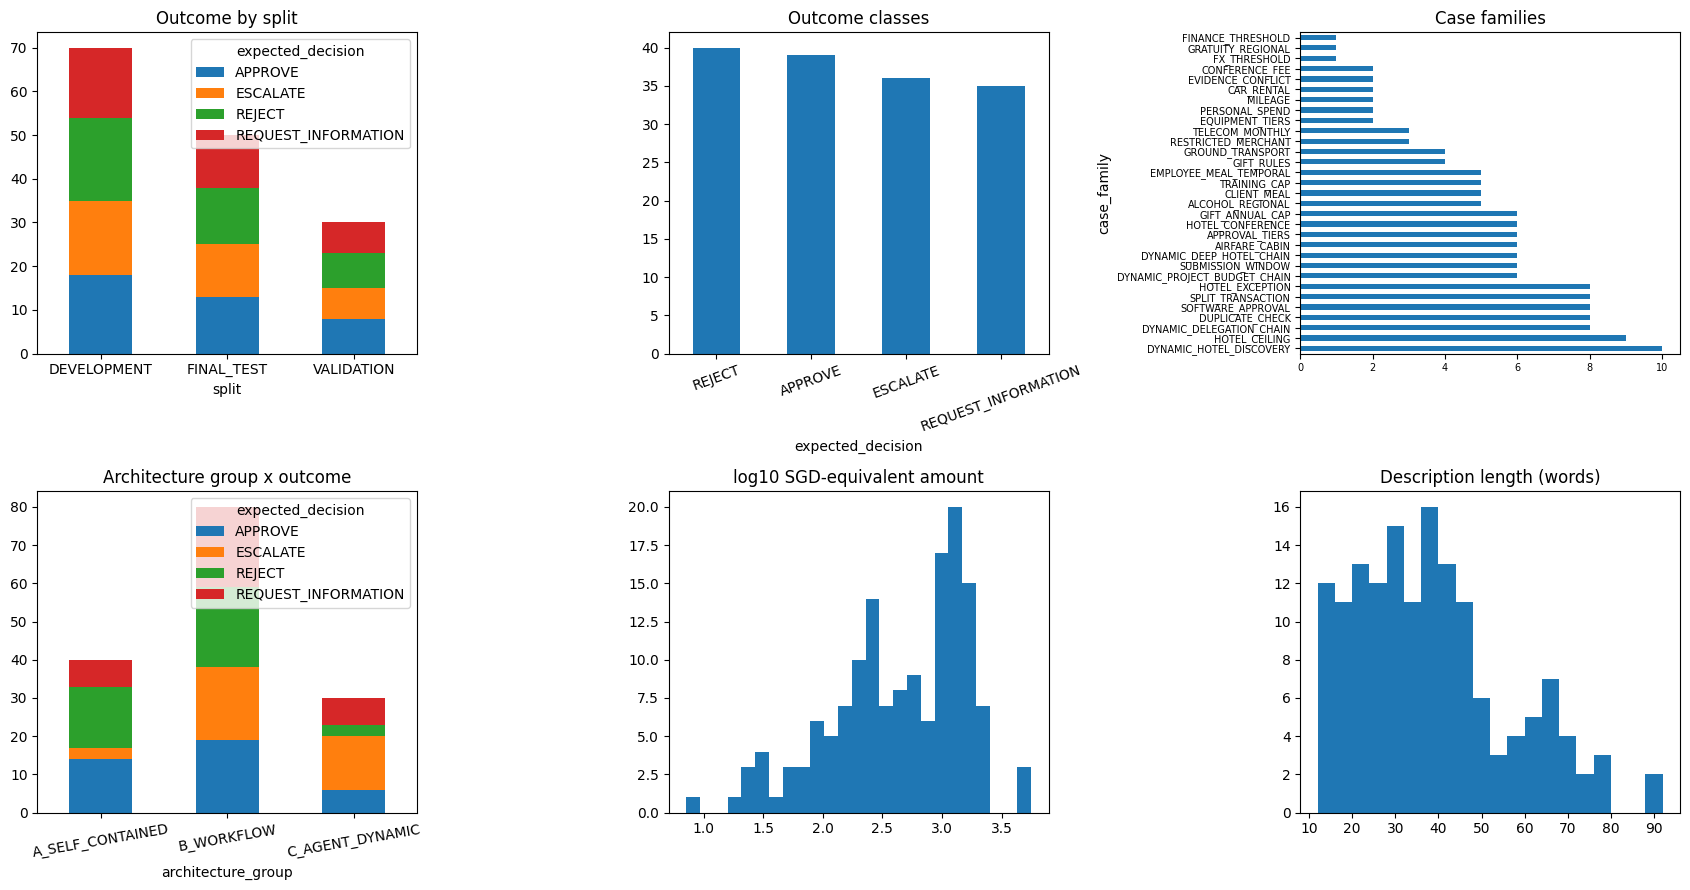

In [11]:
fig, ax = plt.subplots(2,3, figsize=(17,9))
oc = pd.crosstab(df.split, df.expected_decision); oc.plot.bar(stacked=True, ax=ax[0,0], rot=0); ax[0,0].set_title('Outcome by split')
df.expected_decision.value_counts().plot.bar(ax=ax[0,1], rot=20); ax[0,1].set_title('Outcome classes')
df.case_family.value_counts().plot.barh(ax=ax[0,2]); ax[0,2].set_title('Case families'); ax[0,2].tick_params(labelsize=7)
pd.crosstab(df.architecture_group, df.expected_decision).plot.bar(stacked=True, ax=ax[1,0], rot=10); ax[1,0].set_title('Architecture group x outcome')
ax[1,1].hist(np.log10(df.sgd.dropna().clip(lower=1)), bins=25); ax[1,1].set_title('log10 SGD-equivalent amount')
ax[1,2].hist(df.desc_words, bins=20); ax[1,2].set_title('Description length (words)')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp00_eda.png', dpi=130); plt.show()

## 10. Save machine-readable summary

In [12]:
out = C.RESULTS/'exp00'; out.mkdir(parents=True, exist_ok=True)
summary = dict(n_claims=len(df), splits=df.split.value_counts().to_dict(), outcomes=df.expected_decision.value_counts().to_dict(), groups=df.architecture_group.value_counts().to_dict(),
  n_families=int(df.case_family.nunique()), families=df.case_family.value_counts().to_dict(), validator=dict(n_checks=rep['n_checks'],n_failed=rep['n_failed'],passed=rep['passed']), independent_checks=checks.set_index('check').passed.to_dict())
(out/'eda_summary.json').write_text(json.dumps(summary, indent=1, default=bool)); print('saved', out/'eda_summary.json')

saved /Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/results/v2/exp00/eda_summary.json


## Findings and decision
- **150 claims**, split 70 dev / 30 validation / 50 final test. Validator: 45/45 checks pass; independent checks pass (unique IDs, all required policy IDs exist, no label leakage, challenge cases only in final test).
- **4 outcome classes**, nearly balanced (REJECT 26.7%, APPROVE 26.0%, ESCALATE 24.0%, REQUEST_INFORMATION 23.3%). Majority-class baseline is only 26.7%. 111 claims are non-approvable (the False Approval Rate denominator).
- **31 case families** in **3 architecture groups**: A self-contained 40, B workflow 80, C agent-dynamic 30. Difficulty rises A to C (mean controlling clauses 1.3, 3.3, 5.3; mean required tools 0, 2.0, 3.2).
- **Hard by design:** 77% cross-document, 19% temporal amendments, 24% need manual touch, 10% independent challenge cases.
- **Corpus:** 22 policy documents, about 38.8k words (about 50k tokens), so long-context (Exp 4A/4B) is feasible. 11 enterprise tables.
- **Semantic edition:** the visible form is empty and the bill has one generic line; every decision-critical fact lives in a 12-110 word LLM-drafted note (mean 38 words, 6 styles), validated against the hidden facts (149/150 automatically, 1 accepted by hand). Not human-reviewed.
- **Decision:** dataset passes the gate; proceed to Exp 2 (rules baselines) on the semantic edition.